<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/4_Custom_Gradient_Descent_Optimizersipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for tensor computations.
# Only tensor operations are used; torch.optim is not used.
import torch

# Import NumPy for numerical utilities.
import numpy as np

# Import Matplotlib to visualize optimizer convergence.
import matplotlib.pyplot as plt

# Set random seeds for reproducible training results.
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Initialize trainable model parameters.
# Gradients are enabled to allow manual parameter updates.

weights = torch.randn(2, 1, requires_grad=True)
bias = torch.zeros(1, requires_grad=True)

In [3]:
# Implement Momentum Gradient Descent.
# Momentum accumulates previous gradients to accelerate
# optimization and reduce oscillations during training.

class MomentumOptimizer:

    def __init__(self, lr=0.01, momentum=0.9):

        self.lr = lr

        self.momentum = momentum

        self.velocity = {}

    def step(self, params):

        for i, param in enumerate(params):

            if i not in self.velocity:

                # Initialize velocity for every parameter.
                self.velocity[i] = torch.zeros_like(param)

            # Compute exponential moving average of gradients.
            self.velocity[i] = (
                self.momentum * self.velocity[i]
                - self.lr * param.grad
            )

            # Update model parameters.
            param.data += self.velocity[i]

In [4]:
# Implement RMSProp optimization.
# RMSProp adapts the learning rate by maintaining
# a moving average of squared gradients.

class RMSPropOptimizer:

    def __init__(self, lr=0.001, beta=0.9, epsilon=1e-8):

        self.lr = lr

        self.beta = beta

        self.epsilon = epsilon

        self.cache = {}

    def step(self, params):

        for i, param in enumerate(params):

            if i not in self.cache:

                # Initialize squared gradient accumulator.
                self.cache[i] = torch.zeros_like(param)

            # Update moving average of squared gradients.
            self.cache[i] = (
                self.beta * self.cache[i]
                + (1 - self.beta) * param.grad**2
            )

            # Scale parameter updates using adaptive learning rates.
            param.data -= (
                self.lr * param.grad
                / (torch.sqrt(self.cache[i]) + self.epsilon)
            )

In [5]:
# Implement the Adam optimizer from scratch.
# Adam combines Momentum and RMSProp while applying
# bias correction to both moving averages.

class AdamOptimizer:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):

        self.lr = lr

        self.beta1 = beta1

        self.beta2 = beta2

        self.epsilon = epsilon

        self.m = {}

        self.v = {}

        self.t = 0

    def step(self, params):

        self.t += 1

        for i, param in enumerate(params):

            if i not in self.m:

                # Initialize first moment estimate.
                self.m[i] = torch.zeros_like(param)

                # Initialize second moment estimate.
                self.v[i] = torch.zeros_like(param)

            # Update exponential moving average of gradients.
            self.m[i] = (
                self.beta1 * self.m[i]
                + (1 - self.beta1) * param.grad
            )

            # Update exponential moving average of squared gradients.
            self.v[i] = (
                self.beta2 * self.v[i]
                + (1 - self.beta2) * param.grad**2
            )

            # Correct initialization bias in the first moment.
            m_hat = self.m[i] / (1 - self.beta1**self.t)

            # Correct initialization bias in the second moment.
            v_hat = self.v[i] / (1 - self.beta2**self.t)

            # Update parameters using adaptive learning rates.
            param.data -= (
                self.lr * m_hat
                / (torch.sqrt(v_hat) + self.epsilon)
            )

In [6]:
# Generate a simple non-linear dataset to evaluate
# optimizer convergence during training.

X = torch.randn(200,2)

y = (X[:,0]**2 + X[:,1] > 0).float().view(-1,1)

In [7]:
# Compute Mean Squared Error loss between
# predictions and target values.

loss_function = torch.nn.MSELoss()

In [8]:
# Train the model using the selected optimizer.
# The loop performs forward propagation,
# loss computation, gradient calculation,
# parameter updates, and gradient resetting.

optimizer = AdamOptimizer(lr=0.001)

loss_history = []

for epoch in range(100):

    prediction = X @ weights + bias

    loss = loss_function(prediction, y)

    loss.backward()

    optimizer.step([weights, bias])

    loss_history.append(loss.item())

    weights.grad.zero_()

    bias.grad.zero_()

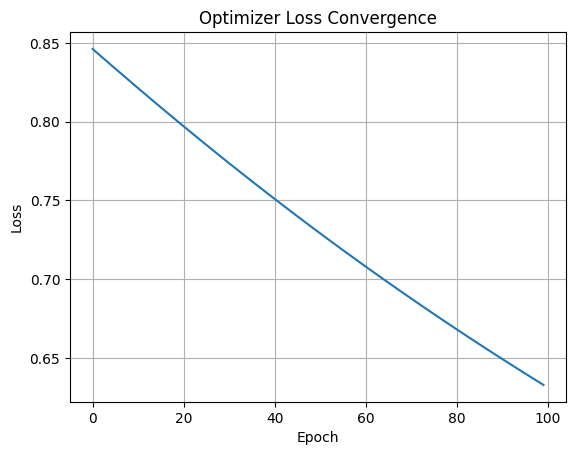

In [9]:
# Plot the training loss across epochs.
# Faster convergence indicates a more effective optimizer.

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Optimizer Loss Convergence")

plt.grid(True)

plt.show()